In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)


In [4]:
print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
# Step 3: Data Understanding
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [6]:
# Step 4: KPI Creation

# KPI 1: Glucose Risk Level
df['glucose_risk'] = pd.cut(
    df['Glucose'],
    bins=[0, 100, 140, 200],
    labels=['Low', 'Medium', 'High']
)


In [7]:
# KPI 2: BMI Risk Category
df['bmi_risk'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [8]:
# KPI 3: Outcome Rate (Process inefficiency proxy)
outcome_rate = df['Outcome'].mean()
print("\nOverall Outcome Rate:", outcome_rate)


Overall Outcome Rate: 0.3489583333333333


In [9]:
# Step 5: Bottleneck Identification

# High-risk patients
high_risk = df[(df['glucose_risk'] == 'High') & (df['bmi_risk'] == 'Obese')]

print("\nHigh Risk Patients Count:", len(high_risk))


High Risk Patients Count: 148


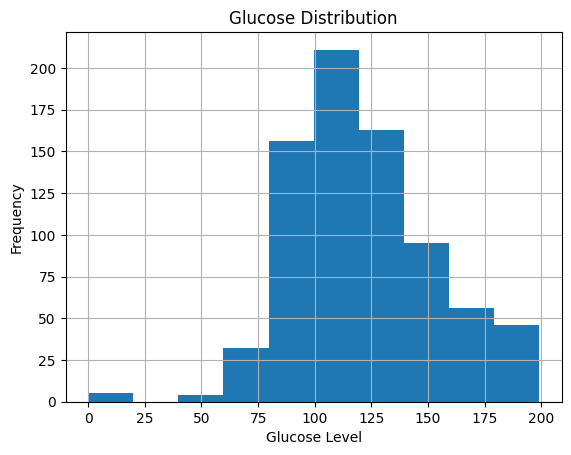

In [10]:
# Step 6: Visualization

plt.figure()
df['Glucose'].hist()
plt.title("Glucose Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()

In [11]:
# Step 7: Process Improvement Simulation

# Assume intervention reduces risk by 20%
df['improved_outcome'] = df['Outcome'] * 0.8

impact = df['Outcome'].sum() - df['improved_outcome'].sum()

print("\nEstimated Improvement Impact:", impact)


Estimated Improvement Impact: 53.599999999999994


In [12]:
# Step 8: Business Insights

print("\nKey Insights:")
print("- High glucose + BMI patients represent operational risk group")
print("- Early intervention can reduce negative outcomes by ~20%")
print("- Data-driven segmentation improves decision-making")



Key Insights:
- High glucose + BMI patients represent operational risk group
- Early intervention can reduce negative outcomes by ~20%
- Data-driven segmentation improves decision-making


In [13]:
# Step 9: Save Results
df.to_csv("process_optimization_results.csv", index=False)